# Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

AZUL = "#13294B"

df_om = pd.read_csv("open_meteo_panama.csv", parse_dates=["Fecha_Hora_Sincro"])
df_om.shape

(35088, 9)

El conjunto de datos se obtuvo mediante la API histórica de Open-Meteo y posteriormente se organizó cronológicamente de acuerdo con la fecha y hora de cada registro. Se utilizaron datos entre las fechas 2022-06-09 al 2026-06-09.

In [3]:
df_om.head(15)

,Fecha_Hora_Sincro,temp_om,hum_om,pressure_om,rad_om,cloud_om,precipitation_om,direct_rad_om,diffuse_rad_om
0,2022-06-09 00:00:00,22.85,96.715744,1010.41650,0.0,36.0,0.0,0.0,0.0
1,2022-06-09 01:00:00,22.40,97.296770,1009.81530,0.0,85.0,0.0,0.0,0.0
2,2022-06-09 02:00:00,22.90,95.546780,1009.51780,0.0,100.0,0.0,0.0,0.0
3,2022-06-09 03:00:00,22.75,95.833534,1009.51730,0.0,100.0,0.0,0.0,0.0
4,2022-06-09 04:00:00,22.50,97.298744,1009.41644,0.0,100.0,0.0,0.0,0.0
5,2022-06-09 05:00:00,22.15,99.090010,1009.71450,0.0,96.0,0.0,0.0,0.0
6,2022-06-09 06:00:00,22.10,99.089660,1010.21350,0.0,89.0,0.0,0.0,0.0
7,2022-06-09 07:00:00,22.90,97.602850,1010.51660,36.0,100.0,0.0,11.0,25.0
8,2022-06-09 08:00:00,24.30,90.528404,1011.12190,197.0,65.0,0.0,101.0,96.0
9,2022-06-09 09:00:00,25.90,85.858800,1011.52830,395.0,85.0,0.0,239.0,156.0


In [4]:
# 1. Cantidad total de NaN por cada columna
print("Valores nulos por columna:")
print(df_om.isnull().sum())

Valores nulos por columna:
Fecha_Hora_Sincro    0
temp_om              0
hum_om               0
pressure_om          0
rad_om               0
cloud_om             0
precipitation_om     0
direct_rad_om        0
diffuse_rad_om       0
dtype: int64


La revisión inicial muestra que las variables obtenidas desde Open-Meteo no presentan valores faltantes en el período analizado.

# Preparación para predecir la radiación solar 1 hora después

Cada fila contiene la información disponible en la hora **t**. La variable objetivo será la radiación de la hora **t+1**.


In [5]:
# Ordenamos cronológicamente antes de crear variables desplazadas
df_om = df_om.sort_values("Fecha_Hora_Sincro").reset_index(drop=True)

# Variables temporales derivadas de la fecha/hora
df_om["hora"] = df_om["Fecha_Hora_Sincro"].dt.hour
df_om["dia_del_anio"] = df_om["Fecha_Hora_Sincro"].dt.dayofyear
df_om["mes"] = df_om["Fecha_Hora_Sincro"].dt.month

# Valores históricos de radiación. Son datos conocidos al momento t.
df_om["rad_lag_1h"] = df_om["rad_om"].shift(1)
df_om["rad_lag_2h"] = df_om["rad_om"].shift(2)
df_om["rad_lag_3h"] = df_om["rad_om"].shift(3)

# OBJETIVO: radiación solar de la próxima hora (t+1)
df_om["rad_objetivo_1h"] = df_om["rad_om"].shift(-1)

df_modelo = df_om

# 2. Explorar

Antes de modelar se revisa el conjunto de datos preparado para conocer su tamaño, los valores faltantes, la distribución de la variable objetivo y su relación con la nubosidad, que es una de las variables centrales de la hipótesis.


In [6]:
df_modelo.head(15)

,Fecha_Hora_Sincro,temp_om,hum_om,pressure_om,rad_om,cloud_om,precipitation_om,direct_rad_om,diffuse_rad_om,hora,dia_del_anio,mes,rad_lag_1h,rad_lag_2h,rad_lag_3h,rad_objetivo_1h
0,2022-06-09 00:00:00,22.85,96.715744,1010.41650,0.0,36.0,0.0,0.0,0.0,0,160,6,NaN,NaN,NaN,0.0
1,2022-06-09 01:00:00,22.40,97.296770,1009.81530,0.0,85.0,0.0,0.0,0.0,1,160,6,0.0,NaN,NaN,0.0
2,2022-06-09 02:00:00,22.90,95.546780,1009.51780,0.0,100.0,0.0,0.0,0.0,2,160,6,0.0,0.0,NaN,0.0
3,2022-06-09 03:00:00,22.75,95.833534,1009.51730,0.0,100.0,0.0,0.0,0.0,3,160,6,0.0,0.0,0.0,0.0
4,2022-06-09 04:00:00,22.50,97.298744,1009.41644,0.0,100.0,0.0,0.0,0.0,4,160,6,0.0,0.0,0.0,0.0
5,2022-06-09 05:00:00,22.15,99.090010,1009.71450,0.0,96.0,0.0,0.0,0.0,5,160,6,0.0,0.0,0.0,0.0
6,2022-06-09 06:00:00,22.10,99.089660,1010.21350,0.0,89.0,0.0,0.0,0.0,6,160,6,0.0,0.0,0.0,36.0
7,2022-06-09 07:00:00,22.90,97.602850,1010.51660,36.0,100.0,0.0,11.0,25.0,7,160,6,0.0,0.0,0.0,197.0
8,2022-06-09 08:00:00,24.30,90.528404,1011.12190,197.0,65.0,0.0,101.0,96.0,8,160,6,36.0,0.0,0.0,395.0
9,2022-06-09 09:00:00,25.90,85.858800,1011.52830,395.0,85.0,0.0,239.0,156.0,9,160,6,197.0,36.0,0.0,590.0


In [7]:
print("Filas y columnas:", df_modelo.shape)

Filas y columnas: (35088, 16)


In [8]:
# Resumen estadístico de la variable objetivo y algunas predictoras principales
df_modelo.describe()

,Fecha_Hora_Sincro,temp_om,hum_om,pressure_om,rad_om,cloud_om,precipitation_om,direct_rad_om,diffuse_rad_om,hora,dia_del_anio,mes,rad_lag_1h,rad_lag_2h,rad_lag_3h,rad_objetivo_1h
count,35088,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35088.000000,35087.000000,35086.000000,35085.000000,35087.000000
mean,2024-06-08 23:30:00,26.544061,81.110859,1009.132347,215.353910,80.044232,0.288278,135.391786,79.962124,11.500000,183.109439,6.522572,215.360048,215.366186,215.372324,215.360048
min,2022-06-09 00:00:00,20.550000,29.040182,1002.959300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-06-09 11:45:00,24.400000,72.590749,1008.022300,0.000000,67.000000,0.000000,0.000000,0.000000,5.750000,92.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,2024-06-08 23:30:00,25.900000,81.619660,1009.154975,13.000000,99.000000,0.000000,0.000000,9.000000,11.500000,183.000000,7.000000,13.000000,13.000000,13.000000,13.000000
75%,2025-06-09 11:15:00,28.350000,94.510749,1010.320400,410.000000,100.000000,0.100000,202.000000,147.000000,17.250000,274.000000,10.000000,410.000000,410.000000,410.000000,410.000000
max,2026-06-09 23:00:00,37.200000,100.000000,1015.729430,1023.000000,100.000000,19.400000,900.000000,472.000000,23.000000,366.000000,12.000000,1023.000000,1023.000000,1023.000000,1023.000000
std,NaN,2.800015,14.387015,1.688716,293.087546,30.599123,1.172160,219.883975,103.964237,6.922285,105.405813,3.447600,293.089467,293.091389,293.093310,293.089467


In [9]:
# b) Valores faltantes
faltan = df_modelo.isna().sum()
print("Valores faltantes por columna:")
print(faltan[faltan > 0])

# Porcentaje total de datos faltantes
porcentaje_faltantes = df_modelo.isna().sum().sum() / df_modelo.size * 100
print("\nPorcentaje total de datos faltantes:", round(porcentaje_faltantes, 5), "%")

Valores faltantes por columna:
rad_lag_1h         1
rad_lag_2h         2
rad_lag_3h         3
rad_objetivo_1h    1
dtype: int64

Porcentaje total de datos faltantes: 0.00125 %


Los valores faltantes se generan únicamente por los desplazamientos temporales realizados. Los rezagos de 1, 2 y 3 horas producen 1, 2 y 3 valores faltantes al inicio de la serie, respectivamente, mientras que la variable objetivo desplazada una hora hacia adelante genera un valor faltante al final. En conjunto representan solo el 0.00125 % de los datos.

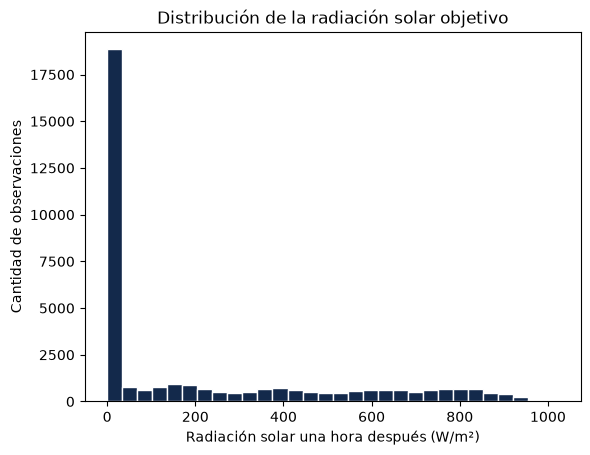

Media: 215.36004788098157
Mediana: 13.0
Desviación estándar: 293.08946722977805
Mínimo: 0.0
Máximo: 1023.0
Skew: 1.0771040614512633


In [10]:
# c) Distribución de la variable objetivo
plt.hist(df_modelo["rad_objetivo_1h"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Radiación solar una hora después (W/m²)")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de la radiación solar objetivo")
plt.show()

# Medidas de resumen de la variable objetivo
print("Media:", df_modelo["rad_objetivo_1h"].mean())
print("Mediana:", df_modelo["rad_objetivo_1h"].median())
print("Desviación estándar:", df_modelo["rad_objetivo_1h"].std())
print("Mínimo:", df_modelo["rad_objetivo_1h"].min())
print("Máximo:", df_modelo["rad_objetivo_1h"].max())
print("Skew:", df_modelo["rad_objetivo_1h"].skew())

Se observa una alta concentración de valores bajos y cercanos a cero, principalmente asociada con las horas nocturnas, mientras que durante las horas de disponibilidad solar se alcanzan valores considerablemente mayores. Esto explica que la media (215.36 W/m²) sea muy superior a la mediana (13 W/m²).

Se observa una cola hacia la derecha ya que la radiación a lo largo del tiempo mantiene muchos datos en cero por las horas en la noche.

In [11]:
correlacion_objetivo = (
    df_modelo
    .corr(numeric_only=True)["rad_objetivo_1h"]
    .sort_values(ascending=False)
)

print(correlacion_objetivo)

rad_objetivo_1h     1.000000
rad_om              0.918370
direct_rad_om       0.880979
temp_om             0.777485
rad_lag_1h          0.753255
diffuse_rad_om      0.725725
rad_lag_2h          0.536130
rad_lag_3h          0.293956
pressure_om         0.155302
hora                0.018307
precipitation_om   -0.013127
dia_del_anio       -0.076113
mes                -0.076396
cloud_om           -0.124842
hum_om             -0.653349
Name: rad_objetivo_1h, dtype: float64


Las variables históricas de radiación son las que presentan una mayor correlación con la variable objetivo, lo que evidencia la importancia de la información temporal reciente para el pronóstico a corto plazo. Asimismo, variables meteorológicas como la temperatura y la humedad relativa presentan correlaciones representativas, por lo que pueden aportar información relevante al modelo predictivo.

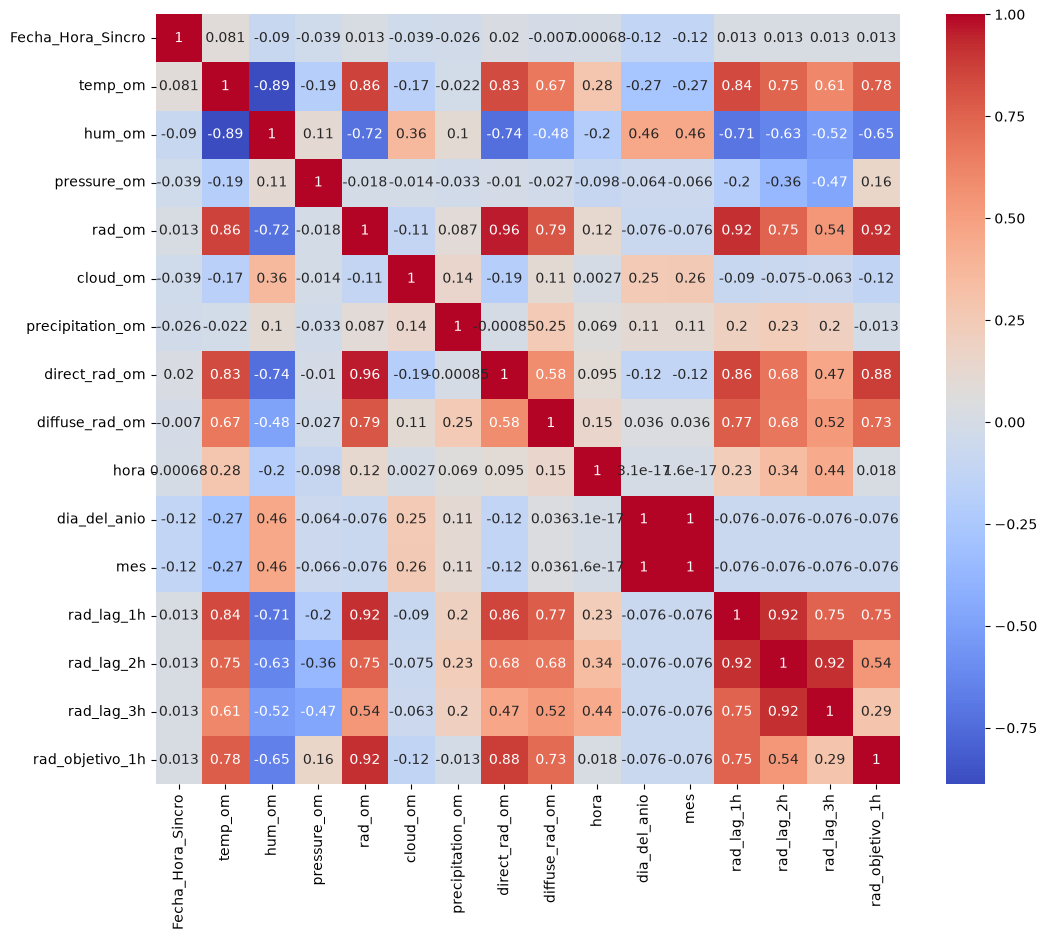

In [12]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_modelo.corr(), annot=True, cmap='coolwarm')
plt.show()

### Correlación nubosidad - radiación

La correlación entre nubosidad y radiación es débil al considerar todas las horas por lo cual se restringe el cálculo a las horas del día para ver la relación.

Correlación nubosidad-radiación (todas las horas): -0.108
Correlación nubosidad-radiación (solo horas con sol): -0.193


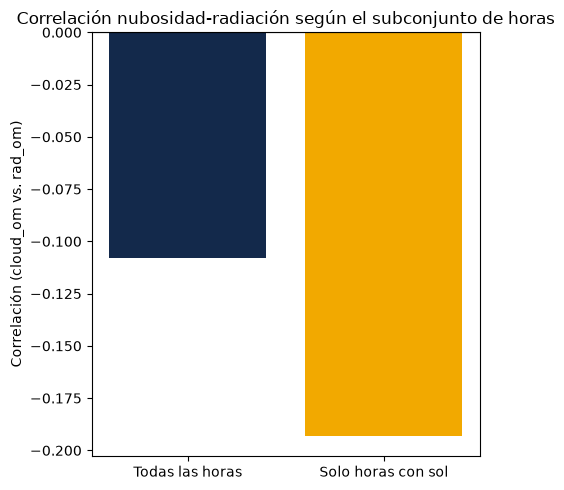

In [13]:
# Correlación nubosidad-radiación
sol_eda = df_modelo["rad_om"] > 0

corr_todas = df_modelo["cloud_om"].corr(df_modelo["rad_om"])
corr_sol = df_modelo.loc[sol_eda, "cloud_om"].corr(df_modelo.loc[sol_eda, "rad_om"])

print("Correlación nubosidad-radiación (todas las horas):", round(corr_todas, 3))
print("Correlación nubosidad-radiación (solo horas con sol):", round(corr_sol, 3))

plt.figure(figsize=(5, 5))
plt.bar(
    ["Todas las horas", "Solo horas con sol"],
    [corr_todas, corr_sol],
    color= [AZUL, "#F2A900"]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Correlación (cloud_om vs. rad_om)")
plt.title("Correlación nubosidad-radiación según el subconjunto de horas")
plt.tight_layout()
plt.show()

Restringido a horas con sol, la correlación entre nubosidad y radiación
pasa de -0.11  a -0.19: de noche hay
nubes y no hay sol, y esa coincidencia diluye la relación cuando se
calcula sobre el total de observaciones.

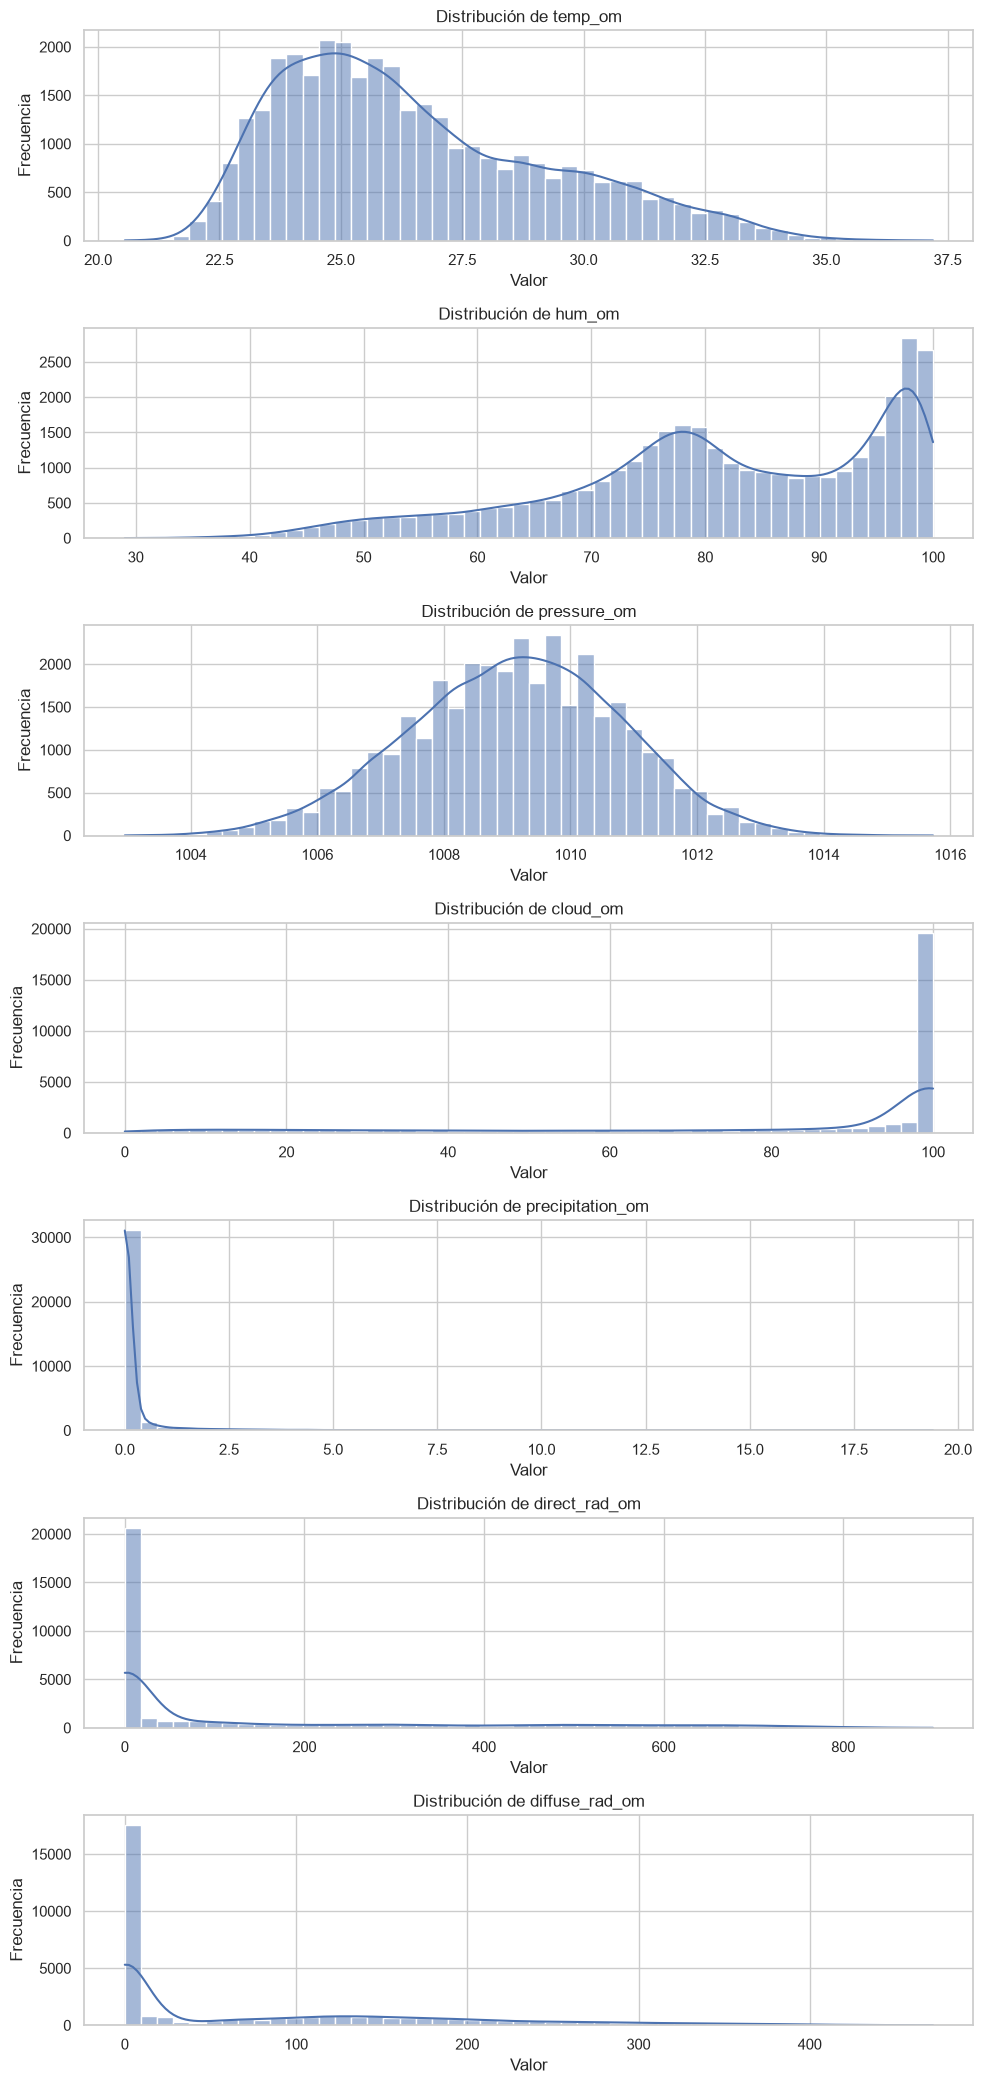

In [14]:
# Variables meteorológicas según los nombres reales de df_om
columnas_meteo = [
    "temp_om",
    "hum_om",
    "pressure_om",
    "cloud_om",
    "precipitation_om",
    "direct_rad_om",
    "diffuse_rad_om"
]

sns.set_theme(style="whitegrid")

n = len(columnas_meteo)

fig, axes = plt.subplots(
    n, 1,
    figsize=(10, 3 * n)
)

if n == 1:
    axes = [axes]

for i, col in enumerate(columnas_meteo):
    sns.histplot(
        df_modelo[col].dropna(),
        ax=axes[i],
        bins=50,
        kde=True
    )

    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Los histogramas muestran distribuciones diferentes de acuerdo con la naturaleza de cada variable meteorológica. La temperatura se concentra principalmente alrededor de 24–28 °C, aunque presenta una extensión hacia temperaturas más altas. La humedad relativa se concentra en valores elevados, con una gran cantidad de observaciones superiores al 70 % y una importante frecuencia de valores cercanos al 100 %. La presión superficial presenta una distribución aproximadamente concentrada alrededor de 1009 hPa y una variabilidad relativamente baja.

La cobertura nubosa muestra una fuerte concentración en valores elevados, particularmente cerca del 100 %, indicando una alta frecuencia de condiciones con considerable cobertura de nubes en los datos analizados. La precipitación presenta una distribución fuertemente asimétrica, con una gran mayoría de horas sin precipitación y un número reducido de eventos de mayor intensidad. Las variables de radiación directa y difusa también presentan una elevada concentración en cero, asociada principalmente con las horas nocturnas, y distribuciones extendidas hacia valores positivos durante las horas de disponibilidad solar.

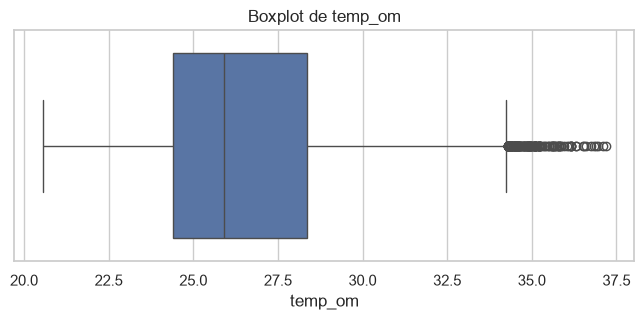

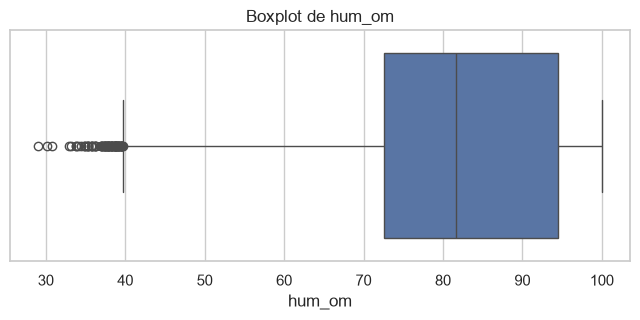

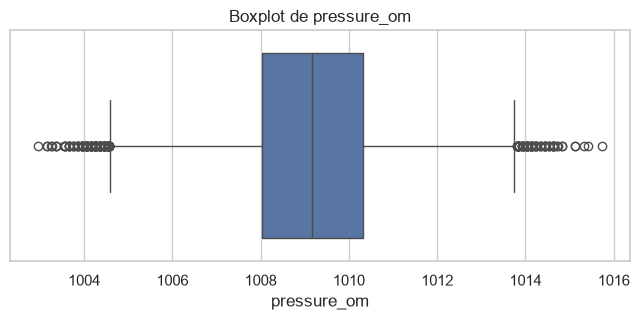

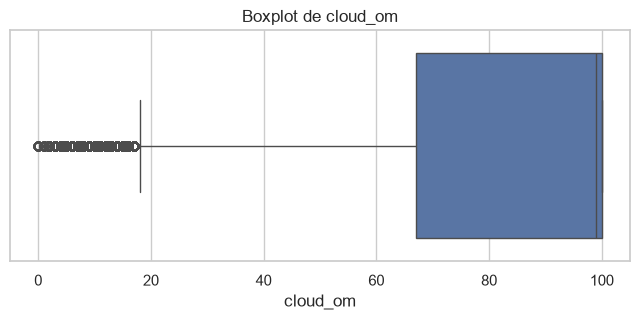

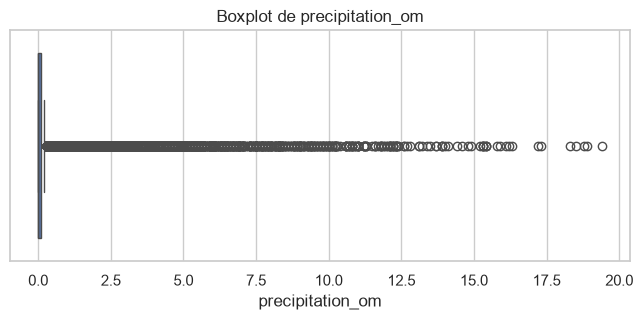

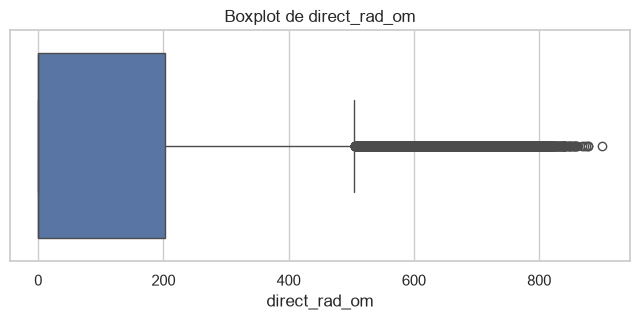

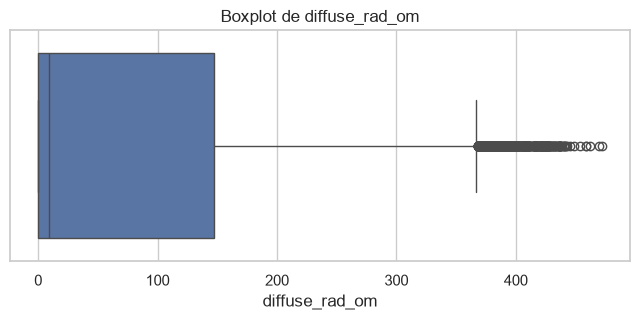

In [15]:
for col in columnas_meteo:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_modelo[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

En variables meteorológicas, eventos menos frecuentes como temperaturas elevadas, baja humedad, lluvias intensas o altos niveles de radiación pueden ser condiciones físicamente válidas. Esto es especialmente evidente en la precipitación, cuya mediana es 0 mm debido a la alta frecuencia de horas sin lluvia, ocasionando que numerosos eventos de precipitación sean identificados estadísticamente como valores atípicos. Por esta razón, los valores extremos no serán eliminados únicamente con base en el criterio del boxplot, sino que deberá evaluarse previamente su coherencia física y temporal.

In [16]:
rangos = {
    "temp_om": (10, 45),              # °C
    "hum_om": (0, 100),               # %
    "pressure_om": (950, 1050),        # hPa
    "cloud_om": (0, 100),             # %
    "rad_om": (0, 1500),              # W/m²
    "direct_rad_om": (0, 1500),       # W/m²
    "diffuse_rad_om": (0, 1000)       # W/m²
}

for variable, (minimo, maximo) in rangos.items():

    condicion = (
        (df_modelo[variable] < minimo) |
        (df_modelo[variable] > maximo)
    )

    print(
        variable,
        "valores fuera de rango:",
        condicion.sum()
    )

temp_om valores fuera de rango: 0
hum_om valores fuera de rango: 0
pressure_om valores fuera de rango: 0
cloud_om valores fuera de rango: 0
rad_om valores fuera de rango: 0
direct_rad_om valores fuera de rango: 0
diffuse_rad_om valores fuera de rango: 0


Adicionalmente, se verificaron los valores de cada variable considerando rangos físicamente posibles. Los valores fuera de estos intervalos se considerarían potencialmente anómalos y serían revisados antes de decidir su eliminación.

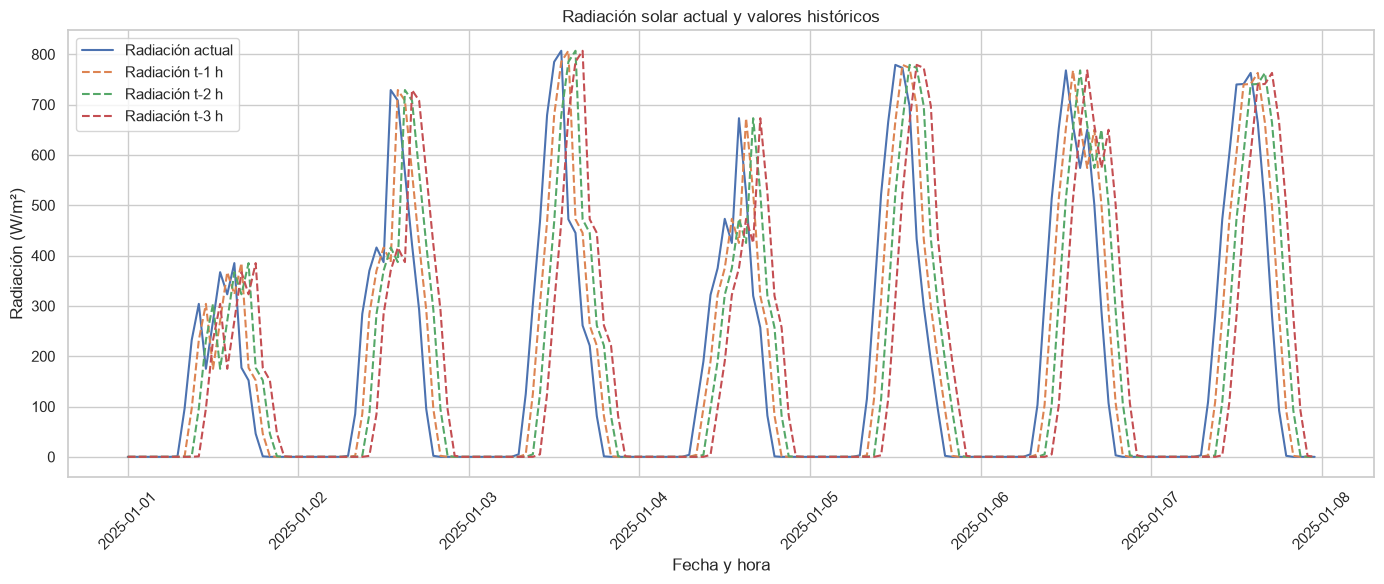

In [17]:
# Seleccionar una semana para visualizar mejor
df_grafica = df_om[
    (df_om["Fecha_Hora_Sincro"] >= "2025-01-01") &
    (df_om["Fecha_Hora_Sincro"] < "2025-01-08")
]

plt.figure(figsize=(14, 6))

plt.plot(
    df_grafica["Fecha_Hora_Sincro"],
    df_grafica["rad_om"],
    label="Radiación actual"
)

plt.plot(
    df_grafica["Fecha_Hora_Sincro"],
    df_grafica["rad_lag_1h"],
    label="Radiación t-1 h",
    linestyle="--"
)

plt.plot(
    df_grafica["Fecha_Hora_Sincro"],
    df_grafica["rad_lag_2h"],
    label="Radiación t-2 h",
    linestyle="--"
)

plt.plot(
    df_grafica["Fecha_Hora_Sincro"],
    df_grafica["rad_lag_3h"],
    label="Radiación t-3 h",
    linestyle="--"
)

plt.title("Radiación solar actual y valores históricos")
plt.xlabel("Fecha y hora")
plt.ylabel("Radiación (W/m²)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa un patrón diario claramente definido, con valores cercanos a cero durante la noche y máximos de radiación durante las horas de mayor disponibilidad solar. Las series rezagadas conservan prácticamente la misma forma que la radiación actual, pero se encuentran desplazadas progresivamente en el tiempo, lo que evidencia una fuerte dependencia temporal de la variable.

## ANÁLISIS FINAL

En conjunto, el análisis exploratorio muestra que la radiación solar presenta una marcada estructura temporal y una fuerte dependencia de sus valores recientes. La radiación de la hora actual constituye la variable con mayor correlación lineal con la radiación de la hora siguiente, lo que respalda el uso de información histórica para un pronóstico de corto plazo. Asimismo, variables meteorológicas como temperatura y humedad presentan relaciones importantes con la variable objetivo, mientras que otras, como nubosidad y precipitación, muestran relaciones lineales menores pero podrían aportar información mediante relaciones no lineales. Las distribuciones observadas también reflejan características propias de los fenómenos meteorológicos, como la elevada frecuencia de radiación nula durante la noche y de precipitación nula durante periodos secos.

## PREPARACIÓN DE LOS DATOS

Variable redundante: rad_om = direct_rad_om + diffuse_rad_om

In [18]:
# Verificación de redundancia entre rad_om y direct_rad_om + diffuse_rad_om
suma_direct_diffuse = df_modelo["direct_rad_om"] + df_modelo["diffuse_rad_om"]
diferencia = df_modelo["rad_om"] - suma_direct_diffuse
correlacion_redundancia = df_modelo["rad_om"].corr(suma_direct_diffuse)

print("Diferencia media (rad_om - (direct_rad_om + diffuse_rad_om)):", round(diferencia.mean(), 2), "W/m²")
print("Correlación rad_om vs. (direct_rad_om + diffuse_rad_om):", round(correlacion_redundancia, 4))

Diferencia media (rad_om - (direct_rad_om + diffuse_rad_om)): 0.0 W/m²
Correlación rad_om vs. (direct_rad_om + diffuse_rad_om): 1.0


La diferencia media es 0.00 W/m² y la correlación es 1.0: Se conserva únicamente rad_om como variable de radiación global en la selección de variables predictoras.

In [19]:
# Eliminamos las filas con NaN generadas por los rezagos y el shift del objetivo
df_ml = df_modelo.dropna().reset_index(drop=True)
df_ml = df_ml.sort_values("Fecha_Hora_Sincro").reset_index(drop=True)

predictoras = [
    "temp_om",            # Temperatura actual
    "hum_om",             # Humedad relativa actual
    "pressure_om",        # Presión atmosférica actual
    "cloud_om",           # Nubosidad actual
    "precipitation_om",   # Precipitación actual
    "rad_om",             # Radiación solar actual
    "rad_lag_1h",         # Radiación de hace 1 hora
    "rad_lag_2h",         # Radiación de hace 2 horas
    "rad_lag_3h",         # Radiación de hace 3 horas
    "hora",               # Hora del día
    "dia_del_anio"        # Día del año
]
objetivo = "rad_objetivo_1h"

# Separar la matriz de características (X) y el vector objetivo (y) 
X = df_ml[predictoras]
y = df_ml[objetivo]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (35084, 11)
Dimensiones de y: (35084,)


In [20]:
# Dividir los datos en entrenamiento y prueba:
# 80 % de los datos más antiguos para entrenamiento y 20 % más reciente para prueba final.
split = int(len(df_ml) * 0.80)

# Como el objetivo está desplazado una hora hacia adelante, dejamos una fila de separación entre train y test.
X_train = X.iloc[:split-1]
y_train = y.iloc[:split-1]

X_test = X.iloc[split:]
y_test = y.iloc[split:]

fechas_test = df_ml['Fecha_Hora_Sincro'].iloc[split:]

print("Entrenamiento:", len(X_train), "| Prueba:", len(X_test))
print("Variables predictoras:", X_train.shape[1])
print("Rango entrenamiento:", df_ml['Fecha_Hora_Sincro'].iloc[0], "->", df_ml['Fecha_Hora_Sincro'].iloc[len(X_train)-1])
print("Rango prueba:", fechas_test.iloc[0], "->", fechas_test.iloc[-1])
print("Porcentaje de filas de prueba con radiación objetivo = 0:", round((y_test == 0).mean() * 100, 2), "%")

Entrenamiento: 28066 | Prueba: 7017
Variables predictoras: 11
Rango entrenamiento: 2022-06-09 03:00:00 -> 2025-08-21 12:00:00
Rango prueba: 2025-08-21 14:00:00 -> 2026-06-09 22:00:00
Porcentaje de filas de prueba con radiación objetivo = 0: 46.97 %


## BASELINE: MODELO DE PERSISTENCIA

In [21]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluar(nombre, modelo, Xtr, ytr, Xte, yte):
    fila = {"Modelo": nombre}
    
    for etiqueta, X_, y_ in (("train", Xtr, ytr), ("test", Xte, yte)):
        pred = modelo.predict(X_)
        
        fila[f"MAE {etiqueta}"] = mean_absolute_error(y_, pred)
        fila[f"RMSE {etiqueta}"] = np.sqrt(mean_squared_error(y_, pred))
        fila[f"R2 {etiqueta}"] = r2_score(y_, pred)
    
    return fila


resultados = []

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

resultados.append(
    evaluar(
        "Baseline (media)",
        baseline,
        X_train, y_train,
        X_test, y_test
    )
)

print(f"Baseline RMSE en prueba: {resultados[0]['RMSE test']:.2f}")
print(f"(equivale a la desviación estándar del objetivo: {y_train.std():.2f})")

Baseline RMSE en prueba: 300.56
(equivale a la desviación estándar del objetivo: 291.21)


In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Modelo de persistencia utilizando la radiacion en tiempo actual ['rad_om']
y_pred_baseline = X_test["rad_om"]

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

y_pred_sol = y_pred_baseline[y_test > 0]
y_test_sol = y_test[y_test > 0]

mae_base_sol = mean_absolute_error(y_test_sol, y_pred_sol)
rmse_base_sol = root_mean_squared_error(y_test_sol, y_pred_sol)
r2_base_sol = r2_score(y_test_sol, y_pred_sol)

print("RESULTADOS DEL BASELINE")
print("-----------------------")
print("MAE:", round(mae_baseline, 2), "W/m²")
print("RMSE:", round(rmse_baseline, 2), "W/m²")
print("R²:", round(r2_baseline, 3))

print("\nRESULTADOS DEL BASELINE (rad > 0)")
print("-----------------------")
print("MAE:", round(mae_base_sol, 2), "W/m²")
print("RMSE:", round(rmse_base_sol, 2), "W/m²")
print("R²:", round(r2_base_sol, 3))

RESULTADOS DEL BASELINE
-----------------------
MAE: 72.73 W/m²
RMSE: 118.09 W/m²
R²: 0.846

RESULTADOS DEL BASELINE (rad > 0)
-----------------------
MAE: 135.75 W/m²
RMSE: 162.0 W/m²
R²: 0.703


## MODELO SIMPLE DE COMPARACIÓN: RIDGE

Además de los modelos base, se incorpora una **regresión Ridge** utilizando las mismas variables predictoras del modelo final. Ridge funciona como un modelo lineal regularizado y permite comprobar si la mayor complejidad de XGBoost realmente aporta una mejora.

Se utiliza `StandardScaler` porque Ridge es sensible a la escala de las variables.


In [23]:
# ============================================================
# MODELO RIDGE
# ============================================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Pipeline:
# 1. StandardScaler estandariza las variables para que estén en escalas comparables.
# 2. Ridge ajusta una regresión lineal con regularización L2.
modelo_ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

# Entrenamos Ridge únicamente con el conjunto de entrenamiento.
modelo_ridge.fit(X_train, y_train)

# Predicciones para entrenamiento y prueba.
pred_ridge_train = modelo_ridge.predict(X_train)
pred_ridge_test = modelo_ridge.predict(X_test)

# La radiación solar no puede ser negativa.
# Ajustamos cualquier predicción menor que cero a 0 W/m².
pred_ridge_train = np.clip(pred_ridge_train, 0, None)
pred_ridge_test = np.clip(pred_ridge_test, 0, None)

# Métricas de entrenamiento.
mae_ridge_train = mean_absolute_error(y_train, pred_ridge_train)
rmse_ridge_train = root_mean_squared_error(y_train, pred_ridge_train)
r2_ridge_train = r2_score(y_train, pred_ridge_train)

# Métricas de prueba: todas las horas.
mae_ridge = mean_absolute_error(y_test, pred_ridge_test)
rmse_ridge = root_mean_squared_error(y_test, pred_ridge_test)
r2_ridge = r2_score(y_test, pred_ridge_test)

# Métricas de prueba: solamente horas con radiación solar.
mascara_sol = y_test > 0
mae_ridge_sol = mean_absolute_error(y_test[mascara_sol], pred_ridge_test[mascara_sol])
rmse_ridge_sol = root_mean_squared_error(y_test[mascara_sol], pred_ridge_test[mascara_sol])
r2_ridge_sol = r2_score(y_test[mascara_sol], pred_ridge_test[mascara_sol])

print("RIDGE - ENTRENAMIENTO")
print("---------------------")
print("MAE:", round(mae_ridge_train, 2), "W/m²")
print("RMSE:", round(rmse_ridge_train, 2), "W/m²")
print("R²:", round(r2_ridge_train, 4))

print("\nRIDGE - PRUEBA (TODAS LAS HORAS)")
print("--------------------------------")
print("MAE:", round(mae_ridge, 2), "W/m²")
print("RMSE:", round(rmse_ridge, 2), "W/m²")
print("R²:", round(r2_ridge, 4))

print("\nRIDGE - PRUEBA (SOLO HORAS CON SOL)")
print("------------------------------------")
print("MAE:", round(mae_ridge_sol, 2), "W/m²")
print("RMSE:", round(rmse_ridge_sol, 2), "W/m²")
print("R²:", round(r2_ridge_sol, 4))


RIDGE - ENTRENAMIENTO
---------------------
MAE: 58.67 W/m²
RMSE: 86.34 W/m²
R²: 0.9121

RIDGE - PRUEBA (TODAS LAS HORAS)
--------------------------------
MAE: 55.1 W/m²
RMSE: 81.79 W/m²
R²: 0.9259

RIDGE - PRUEBA (SOLO HORAS CON SOL)
------------------------------------
MAE: 77.61 W/m²
RMSE: 106.32 W/m²
R²: 0.8721


DummyRegressor (media): predice la radiación promedio.

Persistencia: predice que la próxima hora será igual a la hora actual

## MODELO XGBoost

In [24]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    objective="reg:squarederror",   # el objetivo de regresión: error cuadrático
    random_state=42,
    n_jobs=-1,
)
xgb_base.fit(X_train, y_train)
resultados.append(evaluar("XGBoost por defecto", xgb_base, X_train, y_train, X_test, y_test))

r = resultados[-1]
print(f"MAE  prueba: {r['MAE test']:.2f}")
print(f"RMSE prueba: {r['RMSE test']:.2f}")
print(f"R2   prueba: {r['R2 test']:.4f}")
print(f"\nR2 en entrenamiento: {r['R2 train']:.4f}  <- si es mucho mayor que el de prueba, hay sobreajuste")

MAE  prueba: 23.27
RMSE prueba: 51.62
R2   prueba: 0.9705

R2 en entrenamiento: 0.9877  <- si es mucho mayor que el de prueba, hay sobreajuste


In [25]:
# Validación temporal 
from sklearn.model_selection import TimeSeriesSplit

# Se crean 5 divisiones temporales.
# gap=1 deja una observación entre entrenamiento y validación
tscv = TimeSeriesSplit(
    n_splits=5,
    gap=1
)

print(tscv)

TimeSeriesSplit(gap=1, max_train_size=None, n_splits=5, test_size=None)


In [26]:
from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [27]:
# Hiperparámetros a evaluar
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [28]:
# Grid Search con validación temporal

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know mo

In [29]:
print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor RMSE de validación:")
print(-grid_search.best_score_)

Mejores parámetros:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Mejor RMSE de validación:
51.82802460792217


In [30]:
mejor_modelo = grid_search.best_estimator_

## Evaluación: XGBoost vs Baseline 

In [31]:
# ============================================================
# EVALUACIÓN DEL MEJOR XGBOOST
# ============================================================

# Predicciones del modelo ajustado en entrenamiento y prueba.
pred_xgb_train = mejor_modelo.predict(X_train)
pred_xgb = mejor_modelo.predict(X_test)

# La radiación solar físicamente no puede ser negativa.
# np.clip reemplaza cualquier predicción menor que 0 por 0.
pred_xgb_train = np.clip(pred_xgb_train, 0, None)
pred_xgb = np.clip(pred_xgb, 0, None)

# ----------------------------
# MÉTRICAS DE ENTRENAMIENTO
# ----------------------------
mae_xgb_train = mean_absolute_error(y_train, pred_xgb_train)
rmse_xgb_train = root_mean_squared_error(y_train, pred_xgb_train)
r2_xgb_train = r2_score(y_train, pred_xgb_train)

# ----------------------------
# MÉTRICAS DE PRUEBA: TODAS LAS HORAS
# ----------------------------
mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, pred_xgb)
r2_xgb = r2_score(y_test, pred_xgb)

# ----------------------------
# MÉTRICAS DE PRUEBA: SOLO HORAS CON SOL
# ----------------------------
mascara_sol = y_test > 0

mae_xgb_sol = mean_absolute_error(y_test[mascara_sol], pred_xgb[mascara_sol])
rmse_xgb_sol = root_mean_squared_error(y_test[mascara_sol], pred_xgb[mascara_sol])
r2_xgb_sol = r2_score(y_test[mascara_sol], pred_xgb[mascara_sol])

print("XGBOOST - ENTRENAMIENTO")
print("-----------------------")
print("MAE:", round(mae_xgb_train, 2), "W/m²")
print("RMSE:", round(rmse_xgb_train, 2), "W/m²")
print("R²:", round(r2_xgb_train, 4))

# Tabla de prueba: todas las horas y horas con sol.
comparacion = pd.DataFrame({
    "Modelo": [
        "Persistencia",
        "Persistencia (rad > 0)",
        "Ridge",
        "Ridge (rad > 0)",
        "XGBoost",
        "XGBoost (rad > 0)"
    ],
    "MAE": [
        mae_baseline, mae_base_sol,
        mae_ridge, mae_ridge_sol,
        mae_xgb, mae_xgb_sol
    ],
    "RMSE": [
        rmse_baseline, rmse_base_sol,
        rmse_ridge, rmse_ridge_sol,
        rmse_xgb, rmse_xgb_sol
    ],
    "R2": [
        r2_baseline, r2_base_sol,
        r2_ridge, r2_ridge_sol,
        r2_xgb, r2_xgb_sol
    ]
})

print("\nMÉTRICAS EN EL CONJUNTO DE PRUEBA")
comparacion


XGBOOST - ENTRENAMIENTO
-----------------------
MAE: 21.5 W/m²
RMSE: 45.5 W/m²
R²: 0.9756

MÉTRICAS EN EL CONJUNTO DE PRUEBA


,Modelo,MAE,RMSE,R2
0,Persistencia,72.726806,118.089009,0.845532
1,Persistencia (rad > 0),135.748186,162.004155,0.703057
2,Ridge,55.097470,81.787359,0.925904
3,Ridge (rad > 0),77.605237,106.324540,0.872095
4,XGBoost,22.140285,49.304655,0.973073
5,XGBoost (rad > 0),41.256652,67.694755,0.948152


El análisis se reporta en dos escenarios: **todas las horas** y **solo las horas con radiación solar (`y_test > 0`)**. Esta separación evita que la gran cantidad de observaciones nocturnas con radiación igual a cero haga que las métricas globales parezcan mejores de lo que son durante las horas realmente relevantes para la predicción solar.

La comparación entre **persistencia, Ridge y XGBoost** permite evaluar si la complejidad adicional de XGBoost produce una mejora real frente a métodos más sencillos.


## Importancia de variables

rad_om              0.743902
hora                0.151270
precipitation_om    0.031604
temp_om             0.024529
cloud_om            0.019411
hum_om              0.011932
rad_lag_2h          0.006871
rad_lag_1h          0.002973
dia_del_anio        0.002924
rad_lag_3h          0.002890
pressure_om         0.001694
Name: Importancia, dtype: float32


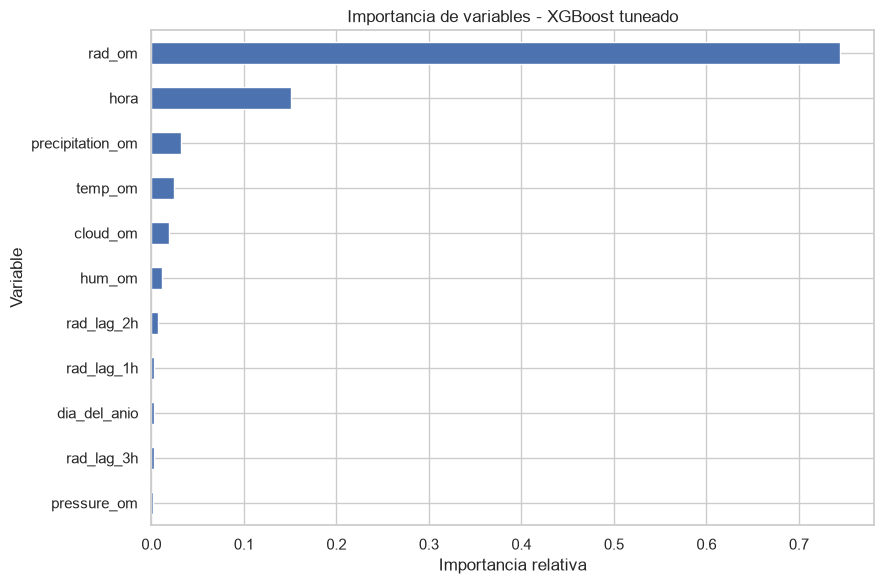

In [32]:
importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=predictoras,
    name="Importancia"
).sort_values(ascending=False)

print(importancias)

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind="barh")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.title("Importancia de variables - XGBoost tuneado")
plt.tight_layout()
plt.show()

## Modelado considerando solo las variables de radiación

In [33]:
# Modelo con solo los rezagos de radiación
predictoras_solo_rezagos = ["rad_om",
                            "rad_lag_1h", 
                            "rad_lag_2h", 
                            "rad_lag_3h", 
                            "hora", 
                            "dia_del_anio" 
                           ]

X_train_rezagos = X_train[predictoras_solo_rezagos]
X_test_rezagos = X_test[predictoras_solo_rezagos]

modelo_xgb_rezagos = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)
#GridSearch
grid_search_rezagos = GridSearchCV(
    estimator=modelo_xgb_rezagos,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_search_rezagos.fit(X_train_rezagos, y_train)
print("Mejores hiperparámetros (solo rezagos):", grid_search_rezagos.best_params_)
print("Mejores hiperparámetros (modelo completo):", grid_search.best_params_)

modelo_xgb_rezagos = grid_search_rezagos.best_estimator_
pred_xgb_rezagos = modelo_xgb_rezagos.predict(X_test_rezagos)
pred_xgb_rezagos = np.clip(pred_xgb_rezagos, 0, None)


rmse_solo_rezagos = root_mean_squared_error(y_test, pred_xgb_rezagos)
r2_solo_rezagos = r2_score(y_test, pred_xgb_rezagos)
reduccion_error = (rmse_solo_rezagos - rmse_xgb) / rmse_solo_rezagos * 100

comparacion_hipotesis = pd.DataFrame({
    "Modelo": ["XGBoost (solo rezagos de radiación)", "XGBoost (con meteorología)"],
    "RMSE": [rmse_solo_rezagos, rmse_xgb],
    "R2": [r2_solo_rezagos, r2_xgb]
})

print(f"La meteorología reduce el RMSE en {reduccion_error:.1f}% frente a usar solo rezagos de radiación.")
comparacion_hipotesis

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparámetros (solo rezagos): {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Mejores hiperparámetros (modelo completo): {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
La meteorología reduce el RMSE en 19.5% frente a usar solo rezagos de radiación.


,Modelo,RMSE,R2
0,XGBoost (solo rezagos de radiación),61.250364,0.958444
1,XGBoost (con meteorología),49.304655,0.973073


Esta comparación prueba directamente la hipótesis del proyecto: se contrasta un XGBoost que utiliza únicamente la radiación actual, sus rezagos y las variables temporales contra el XGBoost completo, que además incorpora las variables meteorológicas. El porcentaje de reducción del RMSE se calcula automáticamente en la celda anterior para evitar dejar un valor escrito que pueda quedar desactualizado si cambia el modelo.


Importancia de variables - XGBoost solo rezagos
rad_om          0.815785
hora            0.150481
dia_del_anio    0.020997
rad_lag_1h      0.004887
rad_lag_3h      0.004218
rad_lag_2h      0.003632
Name: Importancia, dtype: float32


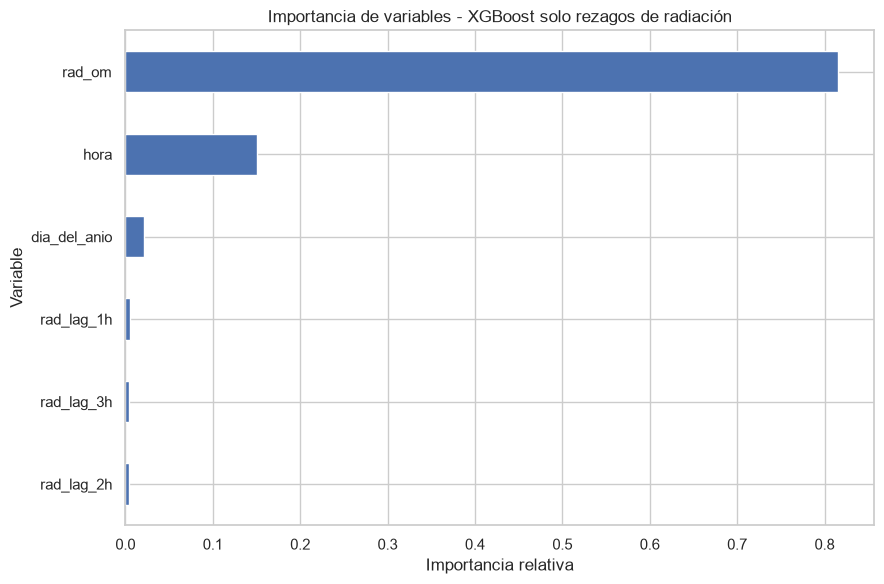

In [37]:
importancias_rezagos = pd.Series(
    modelo_xgb_rezagos.feature_importances_,
    index=predictoras_solo_rezagos,
    name="Importancia"
).sort_values(ascending=False)

print("Importancia de variables - XGBoost solo rezagos")
print(importancias_rezagos)

plt.figure(figsize=(9, 6))

importancias_rezagos.sort_values().plot(kind="barh")

plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.title("Importancia de variables - XGBoost solo rezagos de radiación")

plt.tight_layout()
plt.show()



## RESUMEN FINAL DE MÉTRICAS

La primera tabla compara **entrenamiento y prueba** para Ridge y el XGBoost ajustado. Esto permite revisar si existe una diferencia excesiva entre ambos conjuntos, lo que podría sugerir sobreajuste.

La segunda tabla resume el desempeño en las **horas con sol**, que son las observaciones más exigentes y relevantes para el problema.


In [43]:
# ============================================================
# TABLA FINAL: ENTRENAMIENTO VS. PRUEBA
# ============================================================

resumen_train_test = pd.DataFrame({
    "Modelo": ["Ridge", "XGBoost"],
    "MAE Train": [mae_ridge_train, mae_xgb_train],
    "RMSE Train": [rmse_ridge_train, rmse_xgb_train],
    "R2 Train": [r2_ridge_train, r2_xgb_train],
    "MAE Test": [mae_ridge, mae_xgb],
    "RMSE Test": [rmse_ridge, rmse_xgb],
    "R2 Test": [r2_ridge, r2_xgb]
})

print("ENTRENAMIENTO VS. PRUEBA")
display(resumen_train_test.round(4))

# ============================================================
# TABLA FINAL: SOLO HORAS CON SOL
# ============================================================

resumen_sol = pd.DataFrame({
    "Modelo": ["Persistencia", "Ridge", "XGBoost"],
    "MAE": [mae_base_sol, mae_ridge_sol, mae_xgb_sol],
    "RMSE": [rmse_base_sol, rmse_ridge_sol, rmse_xgb_sol],
    "R2": [r2_base_sol, r2_ridge_sol, r2_xgb_sol]
})

print("\nSOLO HORAS CON SOL (y_test > 0)")
display(resumen_sol.round(4))

# ============================================================
# COMPARACIÓN: SOLO REZAGOS VS. TODAS LAS VARIABLES
# ============================================================

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "XGBoost (solo rezagos)",
        "XGBoost (con meteorología)"
    ],
    
    "MAE Train": [
        mae_xgb_rezagos_train,
        mae_xgb_train
    ],
    
    "RMSE Train": [
        rmse_xgb_rezagos_train,
        rmse_xgb_train
    ],
    
    "R2 Train": [
        r2_xgb_rezagos_train,
        r2_xgb_train
    ],
    
    "MAE Test": [
        mae_xgb_rezagos_test,
        mae_xgb
    ],
    
    "RMSE Test": [
        rmse_xgb_rezagos_test,
        rmse_xgb
    ],
    
    "R2 Test": [
        r2_xgb_rezagos_test,
        r2_xgb
    ]
})

print("COMPARACIÓN: SOLO REZAGOS VS. CON METEOROLOGÍA")
display(comparacion_modelos.round(4))

ENTRENAMIENTO VS. PRUEBA


,Modelo,MAE Train,RMSE Train,R2 Train,MAE Test,RMSE Test,R2 Test
0,Ridge,58.6693,86.3394,0.9121,55.0975,81.7874,0.9259
1,XGBoost,21.4999,45.5000,0.9756,22.1403,49.3047,0.9731



SOLO HORAS CON SOL (y_test > 0)


,Modelo,MAE,RMSE,R2
0,Persistencia,135.7482,162.0042,0.7031
1,Ridge,77.6052,106.3245,0.8721
2,XGBoost,41.2567,67.6948,0.9482


COMPARACIÓN: SOLO REZAGOS VS. CON METEOROLOGÍA


,Modelo,MAE Train,RMSE Train,R2 Train,MAE Test,RMSE Test,R2 Test
0,XGBoost (solo rezagos),32.1571,64.3889,0.9511,30.9025,61.2504,0.9584
1,XGBoost (con meteorología),21.4999,45.5000,0.9756,22.1403,49.3047,0.9731


## ANÁLISIS DE RESIDUOS

Como complemento al gráfico de valores reales frente a predichos, se revisan los **residuos** del XGBoost. Un residuo es la diferencia entre el valor real y el valor predicho. Idealmente, los errores deben distribuirse alrededor de cero sin mostrar un patrón sistemático.


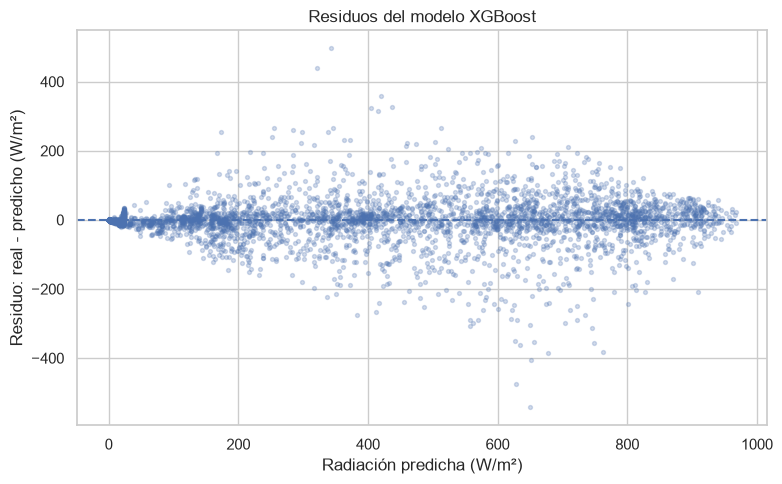

In [40]:
# ============================================================
# GRÁFICA DE RESIDUOS DEL XGBOOST
# ============================================================

residuos_xgb = y_test.to_numpy() - pred_xgb

plt.figure(figsize=(8, 5))
plt.scatter(
    pred_xgb,
    residuos_xgb,
    s=8,
    alpha=0.25
)

# Línea horizontal en cero: representa ausencia de error.
plt.axhline(0, linestyle="--")

plt.xlabel("Radiación predicha (W/m²)")
plt.ylabel("Residuo: real - predicho (W/m²)")
plt.title("Residuos del modelo XGBoost")
plt.tight_layout()
plt.show()


## COMPARACIÓN ACTUAL, BASELINE Y XGBOOST

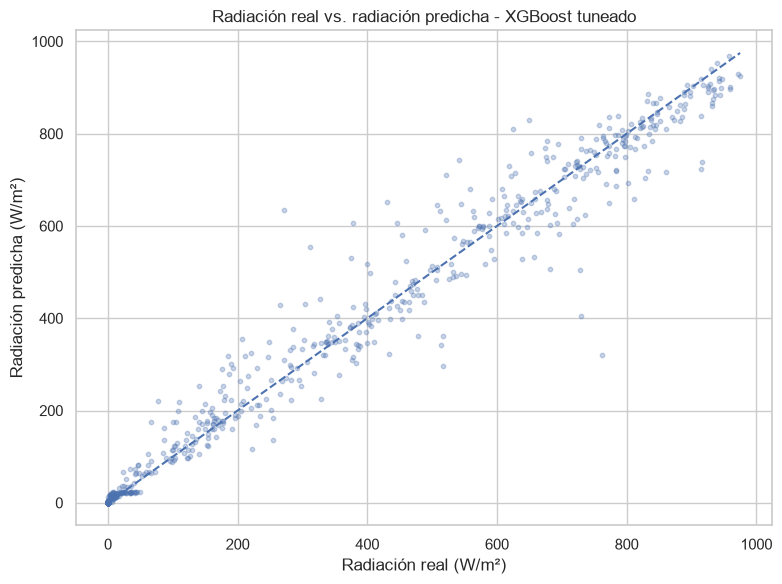

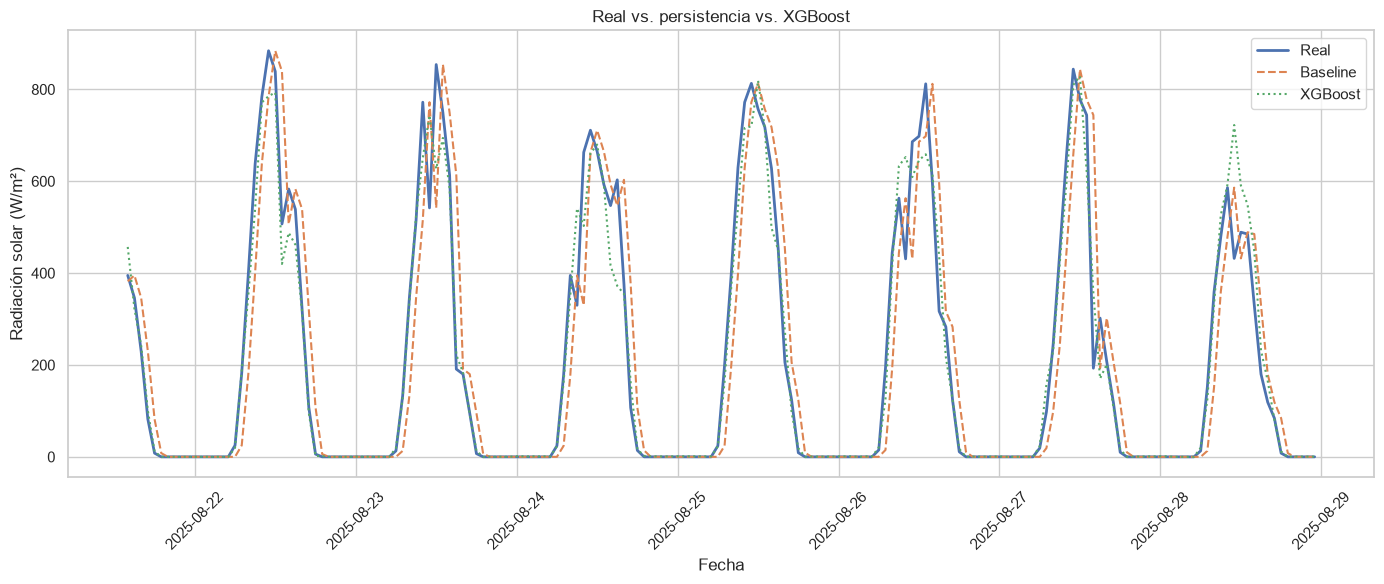

,Fecha_Hora,Radiacion_real,Baseline_persistencia,Radiacion_predicha_XGBoost,Error_XGBoost
28067,2025-08-21 14:00:00,395.0,382.0,456.967651,-61.967651
28068,2025-08-21 15:00:00,346.0,395.0,322.062317,23.937683
28069,2025-08-21 16:00:00,230.0,346.0,242.948441,-12.948441
28070,2025-08-21 17:00:00,82.0,230.0,100.618835,-18.618835
28071,2025-08-21 18:00:00,8.0,82.0,11.767190,-3.767190
28072,2025-08-21 19:00:00,0.0,8.0,0.000000,0.000000
28073,2025-08-21 20:00:00,0.0,0.0,0.000000,0.000000
28074,2025-08-21 21:00:00,0.0,0.0,0.000000,0.000000
28075,2025-08-21 22:00:00,0.0,0.0,0.000000,0.000000
28076,2025-08-21 23:00:00,0.0,0.0,0.000000,0.000000


In [41]:
# Tabla de resultados para las gráficas y revisión de errores.
resultados = pd.DataFrame({
    "Fecha_Hora": fechas_test,
    "Radiacion_real": y_test.to_numpy(),
    "Baseline_persistencia": y_pred_baseline,
    "Radiacion_predicha_XGBoost": pred_xgb
})

resultados["Error_XGBoost"] = (
    resultados["Radiacion_real"] - resultados["Radiacion_predicha_XGBoost"]
)

# Scatter: real vs. predicho.
m = resultados.sample(min(1000, len(resultados)), random_state=1)

plt.figure(figsize=(8, 6))
plt.scatter(
    m["Radiacion_real"],
    m["Radiacion_predicha_XGBoost"],
    s=10,
    alpha=0.3
)

limite = max(
    m["Radiacion_real"].max(),
    m["Radiacion_predicha_XGBoost"].max()
)

plt.plot([0, limite], [0, limite], linestyle="--")
plt.xlabel("Radiación real (W/m²)")
plt.ylabel("Radiación predicha (W/m²)")
plt.title("Radiación real vs. radiación predicha - XGBoost tuneado")
plt.tight_layout()
plt.show()

# Serie temporal de una semana del conjunto de prueba.
mascara = (
    (resultados["Fecha_Hora"] >= '2025-08-21') &
    (resultados["Fecha_Hora"] < '2025-08-29')
)

plt.figure(figsize=(14, 6))
plt.plot(
    resultados.loc[mascara, "Fecha_Hora"],
    resultados.loc[mascara, "Radiacion_real"],
    label="Real",
    linewidth=2
)
plt.plot(
    resultados.loc[mascara, "Fecha_Hora"],
    resultados.loc[mascara, "Baseline_persistencia"],
    label="Baseline",
    linestyle="--"
)
plt.plot(
    resultados.loc[mascara, "Fecha_Hora"],
    resultados.loc[mascara, "Radiacion_predicha_XGBoost"],
    label="XGBoost",
    linestyle=":"
)

plt.xlabel("Fecha")
plt.ylabel("Radiación solar (W/m²)")
plt.title("Real vs. persistencia vs. XGBoost")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

resultados.head(10)